In [21]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("./dados_vendas_pe_ce_ba.csv")

# Exibição das primeiras linhas da tabela

In [2]:
df.head()

,ID,Estado,Cidade,Categoria,Quantidade,Valor_Venda
0,1,BA,Salvador,Alimentos,4,754.47
1,2,PE,Recife,Roupas,9,147.37
2,3,PE,Petrolina,Eletrônicos,2,80.19
3,4,PE,Recife,Roupas,9,621.92
4,5,PE,Petrolina,Roupas,7,716.26


# Quantidade de linhas e colunas da tabela

In [3]:
df.shape

(30, 6)

# Os tipos de dados de cada coluna

In [4]:
df.dtypes

ID               int64
Estado             str
Cidade             str
Categoria          str
Quantidade       int64
Valor_Venda    float64
dtype: object

# Verificação de existência de valores nulos na tabela

In [5]:
df.isnull().sum()

ID             0
Estado         0
Cidade         0
Categoria      0
Quantidade     0
Valor_Venda    0
dtype: int64

# Verificação de valores duplicados na tabela

In [6]:
df.duplicated().sum()

np.int64(0)

# Estatísticas descritivas

In [117]:
df.describe()

,ID,Quantidade,Valor_Venda
count,30.000000,30.000000,30.000000
mean,15.500000,5.400000,496.509667
std,8.803408,3.012617,282.601654
min,1.000000,1.000000,80.190000
25%,8.250000,3.000000,261.672500
50%,15.500000,6.000000,446.640000
75%,22.750000,7.000000,745.687500
max,30.000000,10.000000,985.960000


# Estado que realizou o maior número de vendas

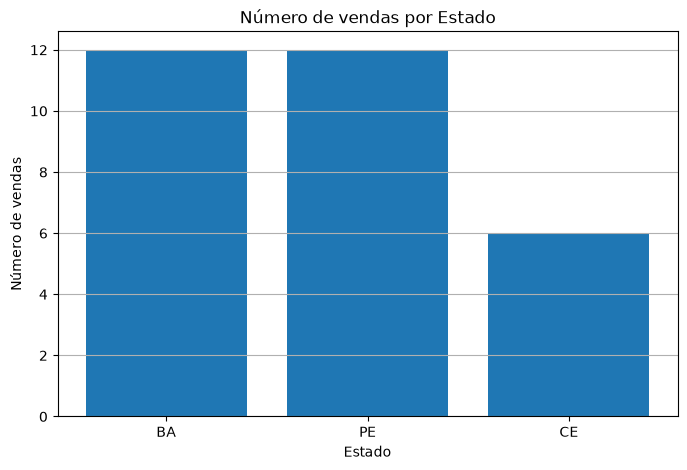

In [86]:
vendas_por_estado = df["Estado"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(vendas_por_estado.index, vendas_por_estado.values)
plt.title("Número de vendas por Estado")
plt.xlabel("Estado")
plt.ylabel("Número de vendas")
plt.grid(axis="y")
plt.show()

# Estado que apresentou a maior quantidade total de produtos vendidos

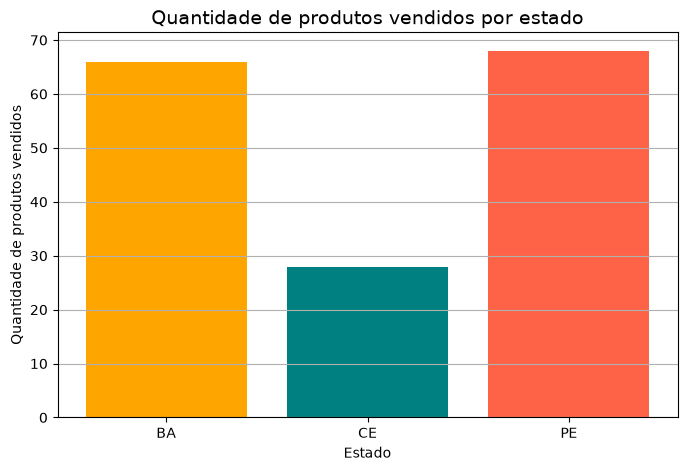

In [98]:
produto_por_estado = (
    df.groupby("Estado")["Quantidade"].sum().reset_index()
)

cores = [
    "orange" if estado == "BA" else "teal" if estado == "CE" else "tomato"
    for estado in produto_por_estado["Estado"]
]

plt.figure(figsize=(8, 5))
plt.bar(produto_por_estado["Estado"], produto_por_estado["Quantidade"], color=cores)
plt.title(f"Quantidade de produtos vendidos por estado", fontsize=14)
plt.xlabel("Estado")
plt.ylabel("Quantidade de produtos vendidos")
plt.grid(axis='y')
plt.show()

# Categoria que possui mais vendas

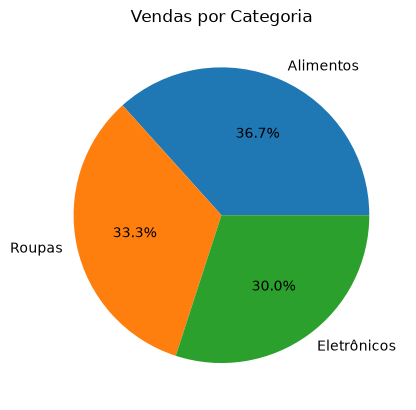

In [96]:
vendas_por_categoria = df["Categoria"].value_counts()

plt.pie(vendas_por_categoria.values,  labels=vendas_por_categoria.index, autopct="%1.1f%%")
plt.title("Vendas por Categoria")
plt.show()

# Categoria que vendeu mais unidades

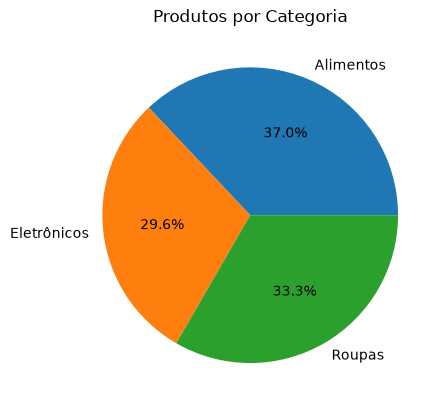

In [111]:
produtos_por_categoria = (
    df.groupby("Categoria")["Quantidade"].sum().reset_index()
)

plt.pie(produtos_por_categoria["Quantidade"], labels=produtos_por_categoria["Categoria"], autopct="%1.1f%%")
plt.title("Produtos por Categoria")
plt.show()